In [1]:
!pip install ucimlrepo

a) Load the Air Quality Index Dataset

In [13]:
from posixpath import pardir
from ucimlrepo import fetch_ucirepo
import pandas as pd

air_quality = fetch_ucirepo(id=360)
df = pd.DataFrame(air_quality.data.features)

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%m/%d/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)

df = df[['NO2(GT)']]

df.head()

,NO2(GT)
Datetime,
2004-03-10 18:00:00,113
2004-03-10 19:00:00,92
2004-03-10 20:00:00,114
2004-03-10 21:00:00,122
2004-03-10 22:00:00,116


b) Plot the target Data

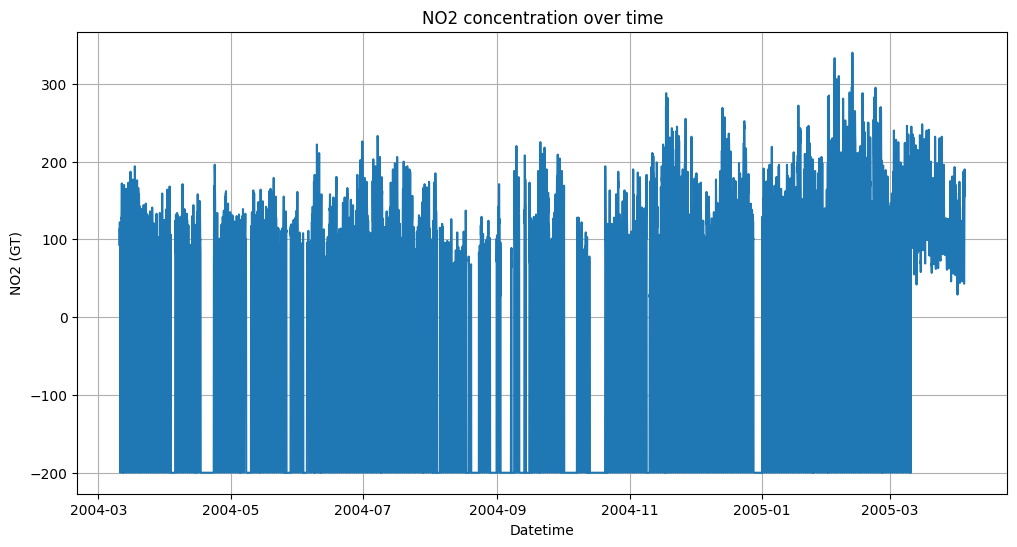

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['NO2(GT)'], label='NO2(GT)')
plt.title('NO2 concentration over time')
plt.xlabel('Datetime')
plt.ylabel('NO2 (GT)')
plt.grid()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['NO2(GT)'].dropna())

print('ADF Statistic:', resultado[0])
print('p-value:', resultado[1])
print('Critérios:', resultado[4])

ADF Statistic: -8.175770351079183
p-value: 8.385433932780482e-13
Critérios: {'1%': np.float64(-3.4310516843596464), '5%': np.float64(-2.861850100263371), '10%': np.float64(-2.5669350612883703)}



**Interpretation:**

- **p-value < 0.05**: The series is stationary.  
- **p-value ≥ 0.05**: The series is non-stationary.

The p-value resulted in $8.385433932780482 \times 10^{-13}$.  
Therefore, the series is **stationary**.

c) Adjust target Data

In [16]:
import numpy as np


def prepare_data(dataset, series='NO2(GT)', lag=2, horizon=1):

  u = dataset[series].to_numpy()

  n = len(u)
  X, y = [], []

  for i in range(n - lag - horizon + 1):
    X.append(u[i : i + lag])
    y.append(u[i + lag + horizon - 1])

  return np.array(X), np.array(y)

X, y = prepare_data(df)

d) Use time series split (5 splits)

In [17]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits = 5)

for train_index, test_index in tss.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    print("X_train:", X_train.ravel(), "y_train:", y_train)
    print("X_test:", X_test.ravel(), "y_test:", y_test)


X_train: [113  92  92 ... 126 126 144] y_train: [114 122 116 ... 126 144 164]
X_test: [144 164 164 ...  70  70  53] y_test: [148 119 111 ...  70  53  54]
X_train: [113  92  92 ...  70  70  53] y_train: [114 122 116 ...  70  53  54]
X_test: [ 53  54  54 ... 152 152 168] y_test: [ 58  73  99 ... 152 168 205]
X_train: [113  92  92 ... 152 152 168] y_train: [114 122 116 ... 152 168 205]
X_test: [168 205 205 ... 126 126 136] y_test: [204 210 173 ... 126 136 156]
X_train: [113  92  92 ... 126 126 136] y_train: [114 122 116 ... 126 136 156]
X_test: [136 156 156 ...  96  96 102] y_test: [187 173 137 ...  96 102  88]
X_train: [113  92  92 ...  96  96 102] y_train: [114 122 116 ...  96 102  88]
X_test: [102  88  88 ... 175 175 156] y_test: [ 87 115 118 ... 175 156 168]


e) Compare 3 regression models (Linear Regression, Random Forest, Naive)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor()

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

y_pred_naive = y_test[:-1]
y_true_naive = y_test[1:]

f) Check MSE and MAE

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

mae_naive = mean_absolute_error(y_true_naive, y_pred_naive)
mse_naive = mean_squared_error(y_true_naive, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)

mase_lr = mae_lr / mae_naive
rrse_lr = rmse_lr / rmse_naive

mase_rf = mae_rf / mae_naive
rrse_rf = rmse_rf / rmse_naive

print("Linear Regression:")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("MASE:", mase_lr)
print("RRSE:", rrse_lr)

print("\nRandom Forest:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MASE:", mase_rf)
print("RRSE:", rrse_rf)

print("\nNaive Forecast:")
print("MAE:", mae_naive)
print("MSE:", mse_naive)
print("RMSE:", rmse_naive)


Linear Regression:
MAE: 38.95032095905486
MSE: 4916.12894762335
RMSE: 70.11511212016529
MASE: 1.0928058211486822
RRSE: 0.904219252407362

Random Forest:
MAE: 36.770737038821466
MSE: 4628.720996418085
RMSE: 68.03470435313204
MASE: 1.0316545408237534
RRSE: 0.877389875702019

Naive Forecast:
MAE: 35.64249037227214
MSE: 6012.786264441592
RMSE: 77.54215798158826


**Interpretation:**  
**MASE < 1** → the model performs better than the naive forecast in terms of absolute error.  
**RRSE < 1** → the model performs better than the naive forecast in terms of squared error.